In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
!pip install pmdarima
from pmdarima.arima import auto_arima

In [2]:
url = "https://raw.githubusercontent.com/Sahdam/TS_Academy_Capstone_Project/refs/heads/main/Model_Data_set.csv"
df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
df.head()

,food_cpi,fuel_price,exchange_rate,basket_cost
Date,,,,
2017-01-31,221.4,148.70,305.20,17028.51
2017-02-28,225.8,149.80,305.31,17171.78
2017-03-31,230.8,149.39,306.40,17846.54
2017-04-30,235.5,149.87,306.05,18087.17
2017-05-31,241.5,150.69,305.54,18632.75


In [3]:
df.tail()

,food_cpi,fuel_price,exchange_rate,basket_cost
Date,,,,
2025-09-30,1220.32,970.59,1503.64,95288.57
2025-10-31,1216.49,1052.31,1465.09,94834.85
2025-11-30,1229.91,1061.35,1444.58,93900.94
2025-12-31,1225.12,1048.63,1452.54,93900.94
2026-01-31,1151.30,795.00,1419.98,93900.94


In [4]:
df = df.asfreq(freq="ME")

In [5]:
df.index

DatetimeIndex(['2017-01-31', '2017-02-28', '2017-03-31', '2017-04-30',
               '2017-05-31', '2017-06-30', '2017-07-31', '2017-08-31',
               '2017-09-30', '2017-10-31',
               ...
               '2025-04-30', '2025-05-31', '2025-06-30', '2025-07-31',
               '2025-08-31', '2025-09-30', '2025-10-31', '2025-11-30',
               '2025-12-31', '2026-01-31'],
              dtype='datetime64[ns]', name='Date', length=109, freq='ME')

In [6]:
train_end = "2025-02-28"
test_start ="2025-03-31"
test_end = "2025-10-30"

In [7]:
train = df.loc[:train_end]
test = df.loc[test_start:test_end]

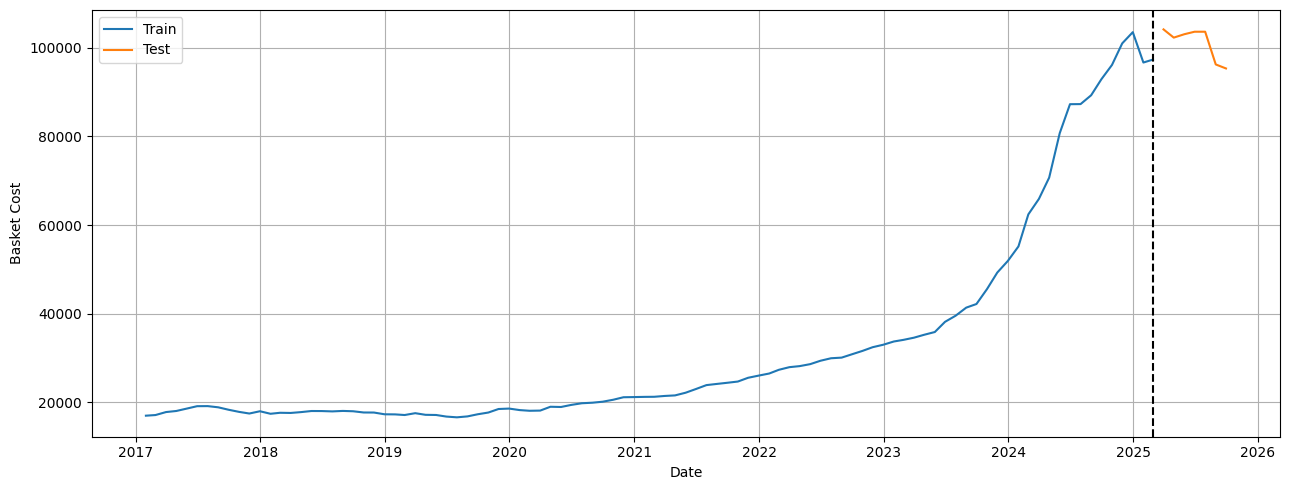

In [28]:
from matplotlib.lines import lineStyles
plt.figure(figsize=(13,5))
plt.plot(train['basket_cost'], label="Train")
plt.plot(test['basket_cost'], label="Test")
plt.axvline(x=train.index[-1], linestyle="--", color="black")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Basket Cost")
plt.grid()
plt.tight_layout()
plt.savefig("train_test_spit", dpi=150, bbox_inches='tight')
plt.show()

In [9]:
from statsmodels.tsa.arima.model import ARIMA

In [10]:
basket_arima = ARIMA(train['basket_cost'], order=(2,2,3)).fit()

In [11]:
basket_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            basket_cost   No. Observations:                   98
Model:                 ARIMA(2, 2, 3)   Log Likelihood                -837.499
Date:                Sat, 07 Mar 2026   AIC                           1686.999
Time:                        23:23:50   BIC                           1702.385
Sample:                    01-31-2017   HQIC                          1693.218
                         - 02-28-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8718      0.272     -3.211      0.001      -1.404      -0.340
ar.L2         -0.6800      0.184     -3.704      0.000      -1.040      -0.320
ma.L1          0.4867      0.306      1.588      0.112      -0.114       1.087
ma.L2          0.0269      0.215      0.125      0.900      -0.394       0.447
ma.L3         -0.4541      0.124     -3.653      0.000      -0.698      -0.210
sigma2      2.136e+06   2.37e+05      8.994      0.000    1.67e+06     2.6e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               865.28
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               6.11   Skew:                            -2.13
Prob(H) (two-sided):                  0.00   Kurtosis:                        17.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
basket_forecast_1 = basket_arima.forecast(steps=len(test))
basket_forecast_1

,predicted_mean
2025-03-31,99879.809636
2025-04-30,99838.633950
2025-05-31,99511.504730
2025-06-30,101225.102148
2025-07-31,101353.973446
2025-08-31,101476.717708
2025-09-30,102682.461750


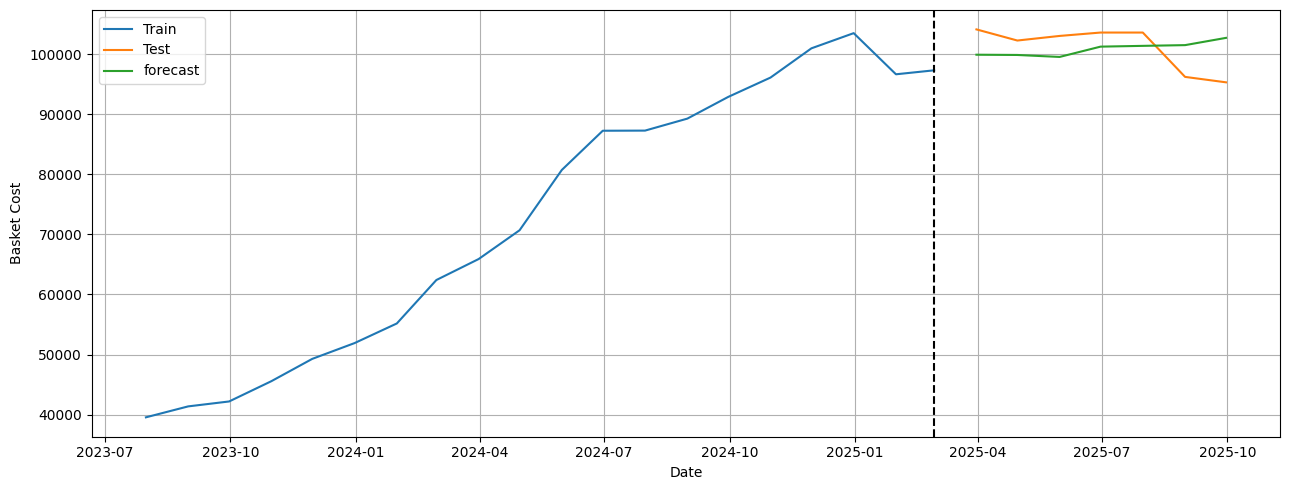

In [29]:
plt.figure(figsize=(13,5))
plt.plot(train['basket_cost'].iloc[-20:], label="Train")
plt.plot(test['basket_cost'], label="Test")
plt.plot(basket_forecast_1, label="forecast")
plt.axvline(x=train.index[-1], linestyle="--", color="black")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Basket Cost")
plt.grid()
plt.tight_layout()
plt.savefig("Arima_forecast", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [15]:
basket_cost_sarimax = SARIMAX(train['basket_cost'], order=(2,2,3), seasonal_order=(0,1,1,12)).fit()
basket_cost_sarimax.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                          basket_cost   No. Observations:                   98
Model:             SARIMAX(2, 2, 3)x(0, 1, [1], 12)   Log Likelihood                -733.287
Date:                              Sat, 07 Mar 2026   AIC                           1480.573
Time:                                      23:23:55   BIC                           1497.589
Sample:                                  01-31-2017   HQIC                          1487.414
                                       - 02-28-2025                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7911      0.102     -7.741      0.000      -0.991      -0.591
ar.L2         -1.0000      0.067    -14.817      0.000      -1.132      -0.868
ma.L1          0.5452      0.159      3.436      0.001       0.234       0.856
ma.L2          0.5058      0.133      3.792      0.000       0.244       0.767
ma.L3         -0.2689      0.152     -1.767      0.077      -0.567       0.029
ma.S.L12      -0.2893      0.252     -1.147      0.252      -0.784       0.205
sigma2       2.17e+06   3.38e+05      6.426      0.000    1.51e+06    2.83e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.18   Jarque-Bera (JB):               254.00
Prob(Q):                              0.67   Prob(JB):                         0.00
Heteroskedasticity (H):               5.04   Skew:                            -1.54
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
basket_forecast_2 = basket_cost_sarimax.forecast(steps=len(test))
basket_forecast_2

,predicted_mean
2025-03-31,98997.508282
2025-04-30,96621.999091
2025-05-31,97958.007396
2025-06-30,102209.076441
2025-07-31,97678.532048
2025-08-31,92695.504921
2025-09-30,94167.804544


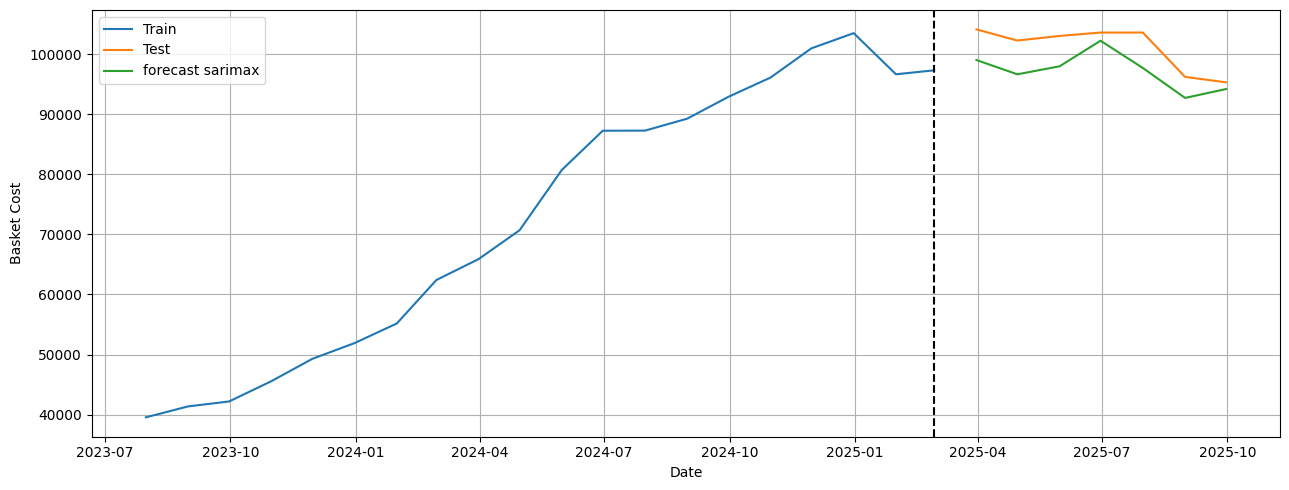

In [30]:
plt.figure(figsize=(13,5))
plt.plot(train['basket_cost'].iloc[-20:], label="Train")
plt.plot(test['basket_cost'], label="Test")
plt.plot(basket_forecast_2, label="forecast sarimax")
plt.axvline(x=train.index[-1], linestyle="--", color="black")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Basket Cost")
plt.grid()
plt.tight_layout()
plt.savefig("Sarimax_forecast", dpi=150, bbox_inches='tight')
plt.show()

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_forecast(test, forecast):
    mse = mean_squared_error(test, forecast)
    mae = mean_absolute_error(test, forecast)
    mape =(np.abs(test - forecast)/test).mean() * 100
    print(f"MSE = {mse:.2f} MAE={mae:.2f} MAPE={mape:.2f}%")
    return mse, mae, mape

In [19]:
actual_basket_cost = test['basket_cost']
arima_forecast = basket_forecast_1
sarimax_forecast = basket_forecast_2

In [20]:
evaluate_forecast(actual_basket_cost, arima_forecast)

MSE = 18389113.64 MAE=3906.64 MAPE=3.92%


(18389113.642795455, 3906.6407923552097, np.float64(3.9205478737945443))

In [21]:
evaluate_forecast(actual_basket_cost, sarimax_forecast)

MSE = 19006908.38 MAE=3947.19 MAPE=3.87%


(19006908.375694696, 3947.18532532028, np.float64(3.871925948121841))

In [22]:
Basket_exog = ['fuel_price', "exchange_rate"]

basket_sarimax_exog = SARIMAX(train['basket_cost'],
                              exog=train[Basket_exog],
                              order=(2,2,3),
                              seasonal_order=(0,1,1,12),
                              enforce_invertibility=False,
                              enforce_stationarity=False).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [23]:
basket_sarimax_exog.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                          basket_cost   No. Observations:                   98
Model:             SARIMAX(2, 2, 3)x(0, 1, [1], 12)   Log Likelihood                -596.572
Date:                              Sat, 07 Mar 2026   AIC                           1211.144
Time:                                      23:24:00   BIC                           1231.120
Sample:                                  01-31-2017   HQIC                          1219.059
                                       - 02-28-2025                                         
Covariance Type:                                opg                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
fuel_price       -0.3344      3.471     -0.096      0.923      -7.138       6.469
exchange_rate     4.4441      2.472      1.798      0.072      -0.400       9.289
ar.L1             0.6040      0.244      2.475      0.013       0.126       1.082
ar.L2            -0.2138      0.191     -1.120      0.263      -0.588       0.160
ma.L1            -1.1419      0.353     -3.230      0.001      -1.835      -0.449
ma.L2             0.1607      0.491      0.327      0.743      -0.802       1.123
ma.L3             0.4960      0.229      2.164      0.030       0.047       0.945
ma.S.L12         -0.3996      0.367     -1.088      0.276      -1.119       0.320
sigma2         2.486e+06   1.11e-05   2.23e+11      0.000    2.49e+06    2.49e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                73.54
Prob(Q):                              0.86   Prob(JB):                         0.00
Heteroskedasticity (H):              16.29   Skew:                            -1.25
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.44
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.75e+26. Standard errors may be unstable.
"""

In [24]:
forecast_3 = basket_sarimax_exog.get_forecast(steps=len(test), exog=test[Basket_exog])
basket_forecast_3 = forecast_3.predicted_mean

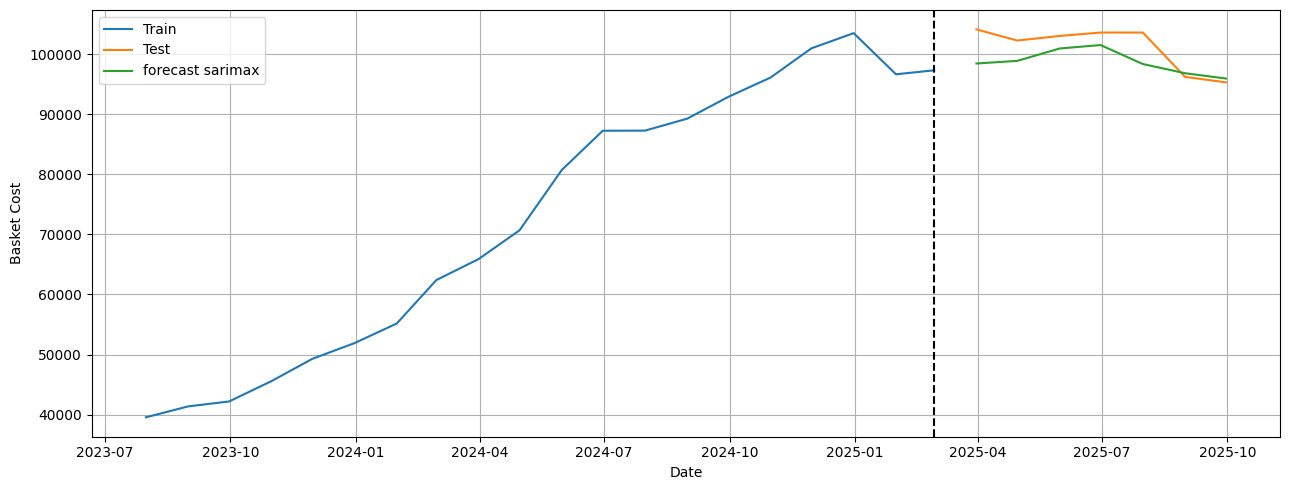

In [31]:
plt.figure(figsize=(13,5))
plt.plot(train['basket_cost'].iloc[-20:], label="Train")
plt.plot(test['basket_cost'], label="Test")
plt.plot(basket_forecast_3, label="forecast sarimax")
plt.axvline(x=train.index[-1], linestyle="--", color="black")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Basket Cost")
plt.grid()
plt.tight_layout()
plt.savefig("Sarima_exog_forecast", dpi=150, bbox_inches='tight')
plt.show()

In [26]:
sarimax_forecast_exog = forecast_3.conf_int(alpha=0.05)

In [27]:
evaluate_forecast(actual_basket_cost, basket_forecast_3)

MSE = 11498346.40 MAE=2814.17 MAPE=2.73%


(11498346.399776025, 2814.1666090125136, np.float64(2.7348856576724745))